# Papaloizou-Pringle Accretion Disk: Scale Calculations

Calculates all physical scales for the Papaloizou-Pringle disk model implementation in Athena++.

**References:** `materials/theory/theory.txt`, `src/pgen/acc_disk.cpp`

## 1. Input Parameters

Set the fundamental parameters for your disk model:
- **M_BH**: Black hole mass
- **r_max**: Distance to disk center (where density peaks)
- **C_prime**: Disk width parameter (0.4-0.5 for moderate thickness)
- **gamma**: Adiabatic index
- **nu**: Dimensionless kinematic viscosity (set to 0 for inviscid)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Get script directory for saving files
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

# Physical Constants (CGS)
c = 2.99792458e10       # Speed of light [cm/s]
G = 6.67430e-8          # Gravitational constant [cm³/(g·s²)]
M_sun = 1.98847e33      # Solar mass [g]
k_B = 1.380649e-16      # Boltzmann constant [erg/K]
m_p = 1.6726219e-24     # Proton mass [g]
pc = 3.086e18           # Parsec [cm]
AU = 1.496e13           # Astronomical unit [cm]
year_to_sec = 365.25 * 24 * 3600
day_to_sec = 24 * 3600

# ==================== INPUT PARAMETERS ====================

# Black hole mass
M_BH_solar = 1.7e7       # [M_sun]

# Distance to disk center (radius of maximum density)
# Choose ONE of the following methods:
input_mode = 'chi'      # Options: 'chi', 'pc', 'cm'

# Disk parameters
C_prime = 0.30          # Disk width parameter
gamma = 5/3             # Adiabatic index (5/3: ideal gas, 4/3: relativistic)
nu = 0.0          # Dimensionless viscosity (0 = inviscid, 10^-4 to 10^-2 typical)

# ==========================================================

if input_mode == 'chi':
    chi = 1000.0         # Dimensionless scaling parameter
    r_max = None        # Will be calculated
elif input_mode == 'pc':
    r_max_pc = 0.01     # [pc]
    r_max = r_max_pc * pc
    chi = None          # Will be calculated
elif input_mode == 'cm':
    r_max_cm = 3.0e17   # [cm]
    r_max = r_max_cm
    chi = None          # Will be calculated

print("="*70)
print("INPUT PARAMETERS")
print("="*70)
print(f"Black hole mass:     M_BH = {M_BH_solar:.2e} M_sun")
print(f"Input mode:          {input_mode}")
if input_mode == 'chi':
    print(f"Scaling parameter:   χ = {chi}")
elif input_mode == 'pc':
    print(f"Disk center radius:  r_max = {r_max_pc} pc")
elif input_mode == 'cm':
    print(f"Disk center radius:  r_max = {r_max_cm:.2e} cm")
print(f"Disk width param:    C' = {C_prime}")
print(f"Adiabatic index:     γ = {gamma:.4f}")
if nu > 0:
    print(f"Viscosity:           ν̃ = {nu:.4e}")
else:
    print(f"Viscosity:           ν̃ = 0 (INVISCID)")
print(f"Save directory:      {script_dir}")
print("="*70)

INPUT PARAMETERS
Black hole mass:     M_BH = 1.70e+07 M_sun
Input mode:          chi
Scaling parameter:   χ = 1000.0
Disk width param:    C' = 0.3
Adiabatic index:     γ = 1.6667
Viscosity:           ν̃ = 0 (INVISCID)
Save directory:      /home/etrevol/athena-collab/materials/theory-scripts


## 2. Calculate Fundamental Scales

Calculate gravitational radius and characteristic scales based on input parameters.

**Formulas:**
- Gravitational radius: $r_g = \frac{2GM}{c^2}$
- Characteristic length: $r_0 = \chi \cdot r_g$
- Characteristic velocity: $v_0 = \frac{c}{\sqrt{2\chi}}$
- Orbital period: $t_0 = 2\pi\sqrt{\frac{r_0^3}{GM}}$
- Polytropic index: $n = \frac{1}{\gamma - 1}$

In [2]:
# Convert mass to CGS
M_BH = M_BH_solar * M_sun

# Gravitational radius
r_g = (2 * G * M_BH) / (c**2)

# Determine chi and r_0 based on input mode
if input_mode == 'chi':
    r_0 = chi * r_g
elif input_mode in ['pc', 'cm']:
    r_0 = r_max
    chi = r_0 / r_g

# Characteristic scales (Equations from theory.txt)
v_0 = c / np.sqrt(2 * chi)                          # Characteristic velocity
t_0 = 2 * np.pi * np.sqrt(r_0**3 / (G * M_BH))     # Orbital period at r_0
n = 1.0 / (gamma - 1.0)                            # Polytropic index

print("="*70)
print("CHARACTERISTIC SCALES")
print("="*70)
print(f"Gravitational radius:       r_g  = {r_g:.4e} cm = {r_g/AU:.4f} AU")
print(f"Scaling parameter:          χ    = {chi:.2f}")
print(f"Characteristic length:      r_0  = {r_0:.4e} cm = {r_0/AU:.2f} AU = {r_0/pc:.4e} pc")
print(f"Characteristic velocity:    v_0  = {v_0:.4e} cm/s = {v_0/c:.6f} c")
print(f"Orbital period at r_0:      t_0  = {t_0:.4e} s = {t_0/day_to_sec:.2f} days")
print(f"Polytropic index:           n    = {n:.4f}")
print("="*70)

CHARACTERISTIC SCALES
Gravitational radius:       r_g  = 5.0207e+12 cm = 0.3356 AU
Scaling parameter:          χ    = 1000.00
Characteristic length:      r_0  = 5.0207e+15 cm = 335.61 AU = 1.6269e-03 pc
Characteristic velocity:    v_0  = 6.7036e+08 cm/s = 0.022361 c
Orbital period at r_0:      t_0  = 4.7058e+07 s = 544.66 days
Polytropic index:           n    = 1.5000


## 3. Disk Structure

Calculate disk boundaries and equilibrium profiles using the Papaloizou-Pringle formula:

$$\frac{\tilde{p}}{\tilde{\rho}} = \frac{1}{n+1}\left(\frac{1}{\tilde{r}} - \frac{1}{2\tilde{r}^2} - C'\right)$$

**Note:** Using sub-Keplerian velocity profile $\tilde{v}_\phi = \frac{1}{\tilde{r}}$

In [3]:
def disk_function(r_tilde, C_prime):
    """Disk equilibrium function. Disk exists where f > 0."""
    return 1.0/r_tilde - 1.0/(2.0*r_tilde**2) - C_prime

def find_disk_edges(C_prime):
    """Find inner and outer disk edges by solving f(r̃) = 0."""
    a = 1.0
    b = -1.0/C_prime
    c = 1.0/(2.0*C_prime)
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return None, None
    r_inner = (-b - np.sqrt(discriminant)) / (2*a)
    r_outer = (-b + np.sqrt(discriminant)) / (2*a)
    return r_inner, r_outer

def calculate_disk_profile(r_tilde, C_prime, n, gamma, density_floor=1e-8):
    """Calculate all physical quantities for the equilibrium disk."""
    f_center = disk_function(1.0, C_prime)
    p_over_rho_center = f_center / (n + 1.0)
    f = disk_function(r_tilde, C_prime)
    
    if f > 0:  # Inside disk
        p_over_rho = f / (n + 1.0)
        rho_tilde = (p_over_rho / p_over_rho_center)**(1.0/(gamma-1.0))
        p_tilde = rho_tilde * p_over_rho
        v_r = 0.0
        v_phi = 1.0 / r_tilde  # Sub-Keplerian velocity
    else:  # Outside disk
        rho_tilde = density_floor
        p_tilde = density_floor * p_over_rho_center
        v_r = 0.0
        v_phi = 1.0 / r_tilde  # Sub-Keplerian velocity
    
    kinetic_energy = 0.5 * rho_tilde * (v_r**2 + v_phi**2)
    internal_energy = p_tilde / (gamma - 1.0)
    E_total = internal_energy + kinetic_energy
    
    return rho_tilde, v_r, v_phi, p_tilde, p_tilde/rho_tilde, E_total

# Find disk boundaries
r_inner, r_outer = find_disk_edges(C_prime)

# Generate radial profiles
r_profile = np.linspace(0.3, 3.0, 500)
profiles = [calculate_disk_profile(r, C_prime, n, gamma) for r in r_profile]
rho_profile = np.array([p[0] for p in profiles])
vr_profile = np.array([p[1] for p in profiles])
vphi_profile = np.array([p[2] for p in profiles])
p_profile = np.array([p[3] for p in profiles])
T_profile = np.array([p[4] for p in profiles])
E_profile = np.array([p[5] for p in profiles])

print("="*70)
print("DISK STRUCTURE")
print("="*70)
print(f"Inner edge:  r̃_in  = {r_inner:.4f} ({r_inner*r_0/AU:.3f} AU)")
print(f"Outer edge:  r̃_out = {r_outer:.4f} ({r_outer*r_0/AU:.3f} AU)")
print(f"Disk width:  Δr̃    = {r_outer-r_inner:.4f}")
print("="*70)

DISK STRUCTURE
Inner edge:  r̃_in  = 0.6126 (205.584 AU)
Outer edge:  r̃_out = 2.7208 (913.105 AU)
Disk width:  Δr̃    = 2.1082


## 4. Viscosity and Timescales

Calculate viscous timescale and equivalent α-parameter.

**Formulas:**
- Physical viscosity: $\nu = \tilde{\nu} \cdot r_0 \cdot v_0$
- Viscous timescale: $\tau_{visc} = \frac{r_0^2}{\nu} = \frac{t_0}{\tilde{\nu}}$
- Equivalent α: $\alpha \approx \frac{\tilde{\nu}}{\gamma \cdot (p/\rho) \cdot r^{3/2}}$ at $r = r_0$

In [4]:
# Physical viscosity
nu_physical = nu * r_0 * v_0

# Viscous timescale (handle inviscid case)
if nu > 0:
    tau_visc_code = 1.0 / nu
    tau_visc_physical = tau_visc_code * t_0
    # Equivalent alpha parameter at r̃ = 1
    p_over_rho_center = disk_function(1.0, C_prime) / (n + 1.0)
    alpha_equiv = nu / (gamma * p_over_rho_center * 1.0**(3.0/2.0))
else:
    tau_visc_code = np.inf
    tau_visc_physical = np.inf
    alpha_equiv = 0.0

print("="*70)
print("VISCOSITY & TIMESCALES")
print("="*70)
if nu > 0:
    print(f"Kinematic viscosity:  ν  = {nu_physical:.4e} cm²/s")
    print(f"                      ν̃  = {nu:.4e} (code units)")
    print(f"Viscous timescale:    τ_visc = {tau_visc_physical:.4e} s")
    print(f"                           = {tau_visc_physical/day_to_sec:.2f} days")
    print(f"                           = {tau_visc_code:.1f} orbits")
    print(f"Equivalent α-param:   α_equiv ≈ {alpha_equiv:.4f}")
else:
    print(f"Kinematic viscosity:  ν̃  = 0 (INVISCID)")
    print(f"Viscous timescale:    τ_visc = ∞ (no viscous evolution)")
    print(f"Equivalent α-param:   α_equiv = 0")
print("="*70)

VISCOSITY & TIMESCALES
Kinematic viscosity:  ν̃  = 0 (INVISCID)
Viscous timescale:    τ_visc = ∞ (no viscous evolution)
Equivalent α-param:   α_equiv = 0


## 5. Simulation Parameters

In [5]:
# Simulation parameters
nx1, nx2, nx3 = 256, 256, 1
x1min, x1max = 0.3, 3.0
x2min, x2max = 0.0, 2*np.pi
cfl = 0.3

# Time limit based on viscosity
if nu > 0:
    tlim_code = 2.0 * tau_visc_code
    dt_output = tau_visc_code / 10.0
else:
    tlim_code = 628.318530718   # 100 orbits
    dt_output = 6.28318530718   # Output every 1 orbit

dfloor, pfloor = 1.0e-8, 1.0e-10

print("="*70)
print("SIMULATION PARAMETERS")
print("="*70)
print(f"\n<mesh>")
print(f"  nx1={nx1}, nx2={nx2}, nx3={nx3}")
print(f"  x1min={x1min}, x1max={x1max}")
print(f"  x2min={x2min}, x2max={x2max:.10f}")
print(f"\n<time>")
print(f"  cfl_number={cfl}")
if nu > 0:
    print(f"  tlim={tlim_code:.2f}  # {tlim_code*t_0/day_to_sec:.1f} days, {tlim_code/tau_visc_code:.1f} visc. times")
else:
    print(f"  tlim={tlim_code:.2f}  # {tlim_code*t_0/day_to_sec:.1f} days (inviscid)")
print(f"\n<hydro>")
print(f"  gamma={gamma:.10f}")
print(f"  nu_iso={nu:.6f}")
print(f"  dfloor={dfloor:.2e}, pfloor={pfloor:.2e}")
print(f"\n<problem>")
print(f"  chi={chi:.2f}")
print(f"  C_prime={C_prime}")
print("="*70)

SIMULATION PARAMETERS

<mesh>
  nx1=256, nx2=256, nx3=1
  x1min=0.3, x1max=3.0
  x2min=0.0, x2max=6.2831853072

<time>
  cfl_number=0.3
  tlim=628.32  # 342217.8 days (inviscid)

<hydro>
  gamma=1.6666666667
  nu_iso=0.000000
  dfloor=1.00e-08, pfloor=1.00e-10

<problem>
  chi=1000.00
  C_prime=0.3


## 6. Visualization

Plot all disk profiles with detailed labels.

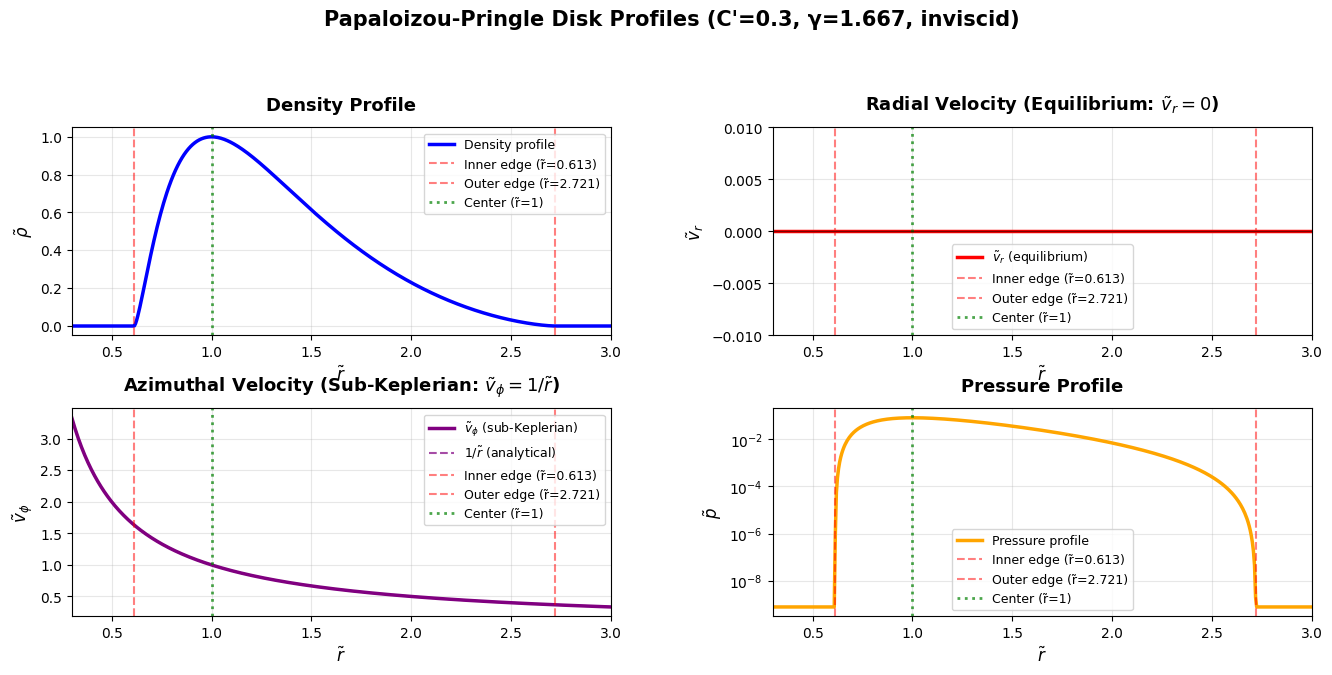

✓ Saved: /home/etrevol/athena-collab/materials/theory-scripts/disk_profiles.png


In [6]:
# Set better style
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Helper function to add disk boundaries with labels
def add_boundaries(ax, show_labels=True):
    line1 = ax.axvline(r_inner, color='r', linestyle='--', alpha=0.5, linewidth=1.5, label=f'Inner edge (r̃={r_inner:.3f})')
    line2 = ax.axvline(r_outer, color='r', linestyle='--', alpha=0.5, linewidth=1.5, label=f'Outer edge (r̃={r_outer:.3f})')
    line3 = ax.axvline(1.0, color='g', linestyle=':', alpha=0.7, linewidth=2, label='Center (r̃=1)')
    if show_labels:
        return [line1, line2, line3]
    return []

# 1. Density
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(r_profile, rho_profile, 'b-', linewidth=2.5, label='Density profile')
lines = add_boundaries(ax1)
ax1.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'$\tilde{\rho}$', fontsize=12, fontweight='bold')
ax1.set_title('Density Profile', fontsize=13, fontweight='bold', pad=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(0.3, 3.0)

# 2. Radial velocity
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(r_profile, vr_profile, 'r-', linewidth=2.5, label=r'$\tilde{v}_r$ (equilibrium)')
add_boundaries(ax2, show_labels=False)
ax2.axhline(0, color='k', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
ax2.set_ylabel(r'$\tilde{v}_r$', fontsize=12, fontweight='bold')
ax2.set_title('Radial Velocity (Equilibrium: $\\tilde{v}_r=0$)', fontsize=13, fontweight='bold', pad=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
ax2.set_xlim(0.3, 3.0)
ax2.set_ylim(-0.01, 0.01)

# 3. Azimuthal velocity
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(r_profile, vphi_profile, 'purple', linewidth=2.5, label=r'$\tilde{v}_\phi$ (sub-Keplerian)')
ax3.plot(r_profile, 1.0/r_profile, 'purple', linestyle='--', linewidth=1.5, alpha=0.7, label=r'$1/\tilde{r}$ (analytical)')
add_boundaries(ax3, show_labels=False)
ax3.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
ax3.set_ylabel(r'$\tilde{v}_\phi$', fontsize=12, fontweight='bold')
ax3.set_title('Azimuthal Velocity (Sub-Keplerian: $\\tilde{v}_\\phi = 1/\\tilde{r}$)', fontsize=13, fontweight='bold', pad=12)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9, loc='upper right')
ax3.set_xlim(0.3, 3.0)

# 4. Pressure
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(r_profile, p_profile, 'orange', linewidth=2.5, label='Pressure profile')
add_boundaries(ax4, show_labels=False)
ax4.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
ax4.set_ylabel(r'$\tilde{p}$', fontsize=12, fontweight='bold')
ax4.set_title('Pressure Profile', fontsize=13, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)
ax4.set_xlim(0.3, 3.0)
ax4.set_yscale('log')

# # 5. Temperature
# ax5 = fig.add_subplot(gs[2, 0])
# ax5.plot(r_profile, T_profile, 'darkred', linewidth=2.5, label=r'$\tilde{T} \propto \tilde{p}/\tilde{\rho}$')
# add_boundaries(ax5, show_labels=False)
# ax5.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
# ax5.set_ylabel(r'$\tilde{T}$', fontsize=12, fontweight='bold')
# ax5.set_title('Temperature Profile (Relative)', fontsize=13, fontweight='bold', pad=12)
# ax5.grid(True, alpha=0.3)
# ax5.legend(fontsize=9)
# ax5.set_xlim(0.3, 3.0)

# # 6. Total energy
# ax6 = fig.add_subplot(gs[2, 1])
# E_internal = p_profile / (gamma - 1.0)
# E_kinetic = 0.5 * rho_profile * vphi_profile**2
# ax6.plot(r_profile, E_profile, 'navy', linewidth=2.5, label='Total energy')
# ax6.plot(r_profile, E_internal, 'b--', linewidth=1.5, alpha=0.7, label='Internal')
# ax6.plot(r_profile, E_kinetic, 'r--', linewidth=1.5, alpha=0.7, label='Kinetic')
# add_boundaries(ax6, show_labels=False)
# ax6.set_xlabel(r'$\tilde{r}$', fontsize=12, fontweight='bold')
# ax6.set_ylabel(r'$\tilde{E}$', fontsize=12, fontweight='bold')
# ax6.set_title('Total Energy Profile', fontsize=13, fontweight='bold', pad=12)
# ax6.grid(True, alpha=0.3)
# ax6.legend(fontsize=9, loc='best')
# ax6.set_xlim(0.3, 3.0)
# ax6.set_yscale('log')

visc_str = f'ν̃={nu:.0e}' if nu > 0 else 'inviscid'
plt.suptitle(f'Papaloizou-Pringle Disk Profiles (C\'={C_prime}, γ={gamma:.3f}, {visc_str})', 
             fontsize=15, fontweight='bold', y=0.998)

plot_path = os.path.join(script_dir, 'disk_profiles.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path}")

## 7. Unified Summary Table

Export all parameters in one comprehensive table.

In [7]:
# Create comprehensive unified table
summary_data = []

# Section 1: Physical Parameters
summary_data.append(['PHYSICAL PARAMETERS', '', '', '', ''])
summary_data.append(['Black Hole Mass', 'M_BH', f'{M_BH/M_sun:.2e}', 'M☉', f'{M_BH:.4e} g'])
summary_data.append(['Gravitational Radius', 'r_g', f'{r_g:.4e}', 'cm', f'{r_g/AU:.4f} AU'])
summary_data.append(['', '', '', '', ''])

# Section 2: Characteristic Scales
summary_data.append(['CHARACTERISTIC SCALES', '', '', '', ''])
summary_data.append(['Scaling Parameter', 'χ', f'{chi:.2f}', '—', 'r₀ = χ·r_g'])
summary_data.append(['Characteristic Length', 'r₀', f'{r_0:.4e}', 'cm', f'{r_0/AU:.2f} AU'])
summary_data.append(['Characteristic Velocity', 'v₀', f'{v_0:.4e}', 'cm/s', f'{v_0/c:.6f} c'])
summary_data.append(['Orbital Period', 't₀', f'{t_0:.4e}', 's', f'{t_0/day_to_sec:.2f} days'])
summary_data.append(['', '', '', '', ''])

# Section 3: Thermodynamic Parameters
summary_data.append(['THERMODYNAMIC PARAMETERS', '', '', '', ''])
summary_data.append(['Adiabatic Index', 'γ', f'{gamma:.6f}', '—', 'EOS parameter'])
summary_data.append(['Polytropic Index', 'n', f'{n:.4f}', '—', 'n = 1/(γ-1)'])
summary_data.append(['', '', '', '', ''])

# Section 4: Disk Structure
summary_data.append(['DISK STRUCTURE', '', '', '', ''])
summary_data.append(['Width Parameter', "C'", f'{C_prime:.3f}', '—', 'determines thickness'])
summary_data.append(['Inner Edge', 'r̃_inner', f'{r_inner:.4f}', '—', f'{r_inner*r_0/AU:.3f} AU'])
summary_data.append(['Outer Edge', 'r̃_outer', f'{r_outer:.4f}', '—', f'{r_outer*r_0/AU:.3f} AU'])
summary_data.append(['Disk Width', 'Δr̃', f'{r_outer-r_inner:.4f}', '—', ''])
summary_data.append(['', '', '', '', ''])

# Section 5: Viscosity
summary_data.append(['VISCOSITY & TIMESCALES', '', '', '', ''])
if nu > 0:
    summary_data.append(['Kinematic Viscosity (code)', 'ν̃', f'{nu:.4e}', '—', 'dimensionless'])
    summary_data.append(['Kinematic Viscosity (phys)', 'ν', f'{nu_physical:.4e}', 'cm²/s', 'ν = ν̃·r₀·v₀'])
    summary_data.append(['Viscous Timescale (code)', 'τ_visc', f'{tau_visc_code:.1f}', 't₀', f'{tau_visc_code:.0f} orbits'])
    summary_data.append(['Viscous Timescale (phys)', 'τ_visc', f'{tau_visc_physical:.4e}', 's', f'{tau_visc_physical/day_to_sec:.1f} days'])
    summary_data.append(['Equivalent α-parameter', 'α_equiv', f'{alpha_equiv:.4f}', '—', 'for reference'])
else:
    summary_data.append(['Kinematic Viscosity', 'ν̃', '0', '—', 'INVISCID'])
    summary_data.append(['Viscous Timescale', 'τ_visc', '∞', '—', 'no viscous evolution'])
    summary_data.append(['Equivalent α-parameter', 'α_equiv', '0', '—', ''])
summary_data.append(['', '', '', '', ''])

# Section 6: Simulation Parameters
summary_data.append(['SIMULATION PARAMETERS', '', '', '', ''])
summary_data.append(['Radial Resolution', 'nx1', f'{nx1}', 'cells', ''])
summary_data.append(['Azimuthal Resolution', 'nx2', f'{nx2}', 'cells', ''])
summary_data.append(['Radial Domain', '[x1min,x1max]', f'[{x1min},{x1max}]', '—', f'{x1min*r_0/AU:.2f}-{x1max*r_0/AU:.2f} AU'])
summary_data.append(['Azimuthal Domain', '[x2min,x2max]', f'[0,2π]', 'rad', 'full circle'])
summary_data.append(['CFL Number', 'cfl', f'{cfl}', '—', 'stability'])
summary_data.append(['Simulation Time', 'tlim', f'{tlim_code:.2f}', 't₀', f'{tlim_code*t_0/day_to_sec:.1f} days'])
summary_data.append(['Output Cadence', 'dt_output', f'{dt_output:.2f}', 't₀', f'{dt_output*t_0/day_to_sec:.2f} days'])
summary_data.append(['Density Floor', 'dfloor', f'{dfloor:.1e}', '—', 'numerical stability'])
summary_data.append(['Pressure Floor', 'pfloor', f'{pfloor:.1e}', '—', 'numerical stability'])

# Create DataFrame
summary_df = pd.DataFrame(summary_data, columns=['Parameter', 'Symbol', 'Value', 'Units', 'Notes'])

# Display
print("="*90)
print("COMPREHENSIVE PARAMETER SUMMARY")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)

# Save to CSV
csv_path = os.path.join(script_dir, 'parameters_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Table saved to: {csv_path}")

COMPREHENSIVE PARAMETER SUMMARY
               Parameter        Symbol      Value Units                Notes
     PHYSICAL PARAMETERS                                                    
         Black Hole Mass          M_BH   1.70e+07    M☉         3.3804e+40 g
    Gravitational Radius           r_g 5.0207e+12    cm            0.3356 AU
                                                                            
   CHARACTERISTIC SCALES                                                    
       Scaling Parameter             χ    1000.00     —           r₀ = χ·r_g
   Characteristic Length            r₀ 5.0207e+15    cm            335.61 AU
 Characteristic Velocity            v₀ 6.7036e+08  cm/s           0.022361 c
          Orbital Period            t₀ 4.7058e+07     s          544.66 days
                                                                            
THERMODYNAMIC PARAMETERS                                                    
         Adiabatic Index             γ   1.6

## 8. Final Report in Athena++ Input Format

Generate markdown report with exact Athena++ input file format and formulas.

In [8]:
# Generate Athena++ formatted report with formulas
def sci_to_latex(value, precision=4):
    """Convert scientific notation to LaTeX format: 1.23e+12 -> 1.23 × 10^{12}"""
    formatted = f"{value:.{precision}e}"
    if 'e' in formatted:
        mantissa, exponent = formatted.split('e')
        exponent = int(exponent)
        return f"{mantissa} \\times 10^{{{exponent}}}"
    return formatted

report = f"""# Papaloizou-Pringle Disk: Calculation Report

**Generated:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Black Hole Mass:** M_BH = {M_BH_solar:.2e} M☉  
**Scaling:** χ = {chi:.2f}, C' = {C_prime}, γ = {gamma:.6f}  
**Viscosity:** ν̃ = {nu:.4e} {'(INVISCID)' if nu == 0 else ''}

---

## Fundamental Formulas

### Gravitational Radius
$$r_g = \\frac{{2GM}}{{c^2}} = {sci_to_latex(r_g, 4)} \\text{{ cm}} = {r_g/AU:.4f} \\text{{ AU}}$$

### Characteristic Scales
$$r_0 = \\chi \\cdot r_g = {sci_to_latex(r_0, 4)} \\text{{ cm}} = {r_0/AU:.2f} \\text{{ AU}}$$

$$v_0 = \\frac{{c}}{{\\sqrt{{2\\chi}}}} = {sci_to_latex(v_0, 4)} \\text{{ cm/s}} = {v_0/c:.6f} \\, c$$

$$t_0 = 2\\pi\\sqrt{{\\frac{{r_0^3}}{{GM}}}} = {sci_to_latex(t_0, 4)} \\text{{ s}} = {t_0/day_to_sec:.2f} \\text{{ days}}$$

### Polytropic Index
$$n = \\frac{{1}}{{\\gamma - 1}} = {n:.4f}$$

### Disk Boundaries
Solve: $f(\\tilde{{r}}) = \\frac{{1}}{{\\tilde{{r}}}} - \\frac{{1}}{{2\\tilde{{r}}^2}} - C' = 0$

$$\\tilde{{r}}_{{\\text{{inner}}}} = {r_inner:.4f} \\quad (r = {r_inner*r_0/AU:.3f} \\text{{ AU}})$$

$$\\tilde{{r}}_{{\\text{{outer}}}} = {r_outer:.4f} \\quad (r = {r_outer*r_0/AU:.3f} \\text{{ AU}})$$

### Equilibrium Pressure-Density Relation
$$\\frac{{\\tilde{{p}}}}{{\\tilde{{\\rho}}}} = \\frac{{1}}{{n+1}}\\left(\\frac{{1}}{{\\tilde{{r}}}} - \\frac{{1}}{{2\\tilde{{r}}^2}} - C'\\right)$$

### Velocity Profile (Sub-Keplerian)
$$\\tilde{{v}}_r = 0 \\quad \\text{{(equilibrium)}}$$

$$\\tilde{{v}}_\\phi = \\frac{{1}}{{\\tilde{{r}}}} \\quad \\text{{(sub-Keplerian)}}$$

### Viscosity
"""

if nu > 0:
    report += f"""$$\\nu = \\tilde{{\\nu}} \\cdot r_0 \\cdot v_0 = {sci_to_latex(nu_physical, 4)} \\text{{ cm}}^2/\\text{{s}}$$

$$\\tau_{{\\text{{visc}}}} = \\frac{{r_0^2}}{{\\nu}} = \\frac{{t_0}}{{\\tilde{{\\nu}}}} = {tau_visc_code:.0f} \\text{{ orbits}} = {tau_visc_physical/day_to_sec:.1f} \\text{{ days}}$$

$$\\alpha_{{\\text{{equiv}}}} \\approx \\frac{{\\tilde{{\\nu}}}}{{\\gamma \\cdot (p/\\rho) \\cdot r^{{3/2}}}}\\bigg|_{{r=r_0}} \\approx {alpha_equiv:.4f}$$
"""
else:
    report += f"""$$\\tilde{{\\nu}} = 0 \\quad \\text{{(INVISCID - no viscous evolution)}}$$
"""

report += f"""
---

## Athena++ Input File Format

```
<comment>
problem   = Papaloizou-Pringle accretion disk
reference = theory.txt
configure = --prob=acc_disk --coord=cylindrical

<job>
problem_id = acc_disk      # Problem identifier

<output1>
file_type  = hdf5          # HDF5 output format
variable   = prim          # Primitive variables (rho, v, p)
dt         = {dt_output:.6f}      # Output cadence [{dt_output*t_0/day_to_sec:.2f} days]
dcycle     = -1            # Disable cycle-based output

<time>
cfl_number = {cfl}            # CFL stability condition
nlim       = -1            # No cycle limit (use tlim)
tlim       = {tlim_code:.6f}      # End time [{tlim_code*t_0/day_to_sec:.1f} days]
integrator = vl2           # Van Leer 2nd order integrator
xorder     = 2             # 2nd order spatial reconstruction
ncycle_out = 10            # Console output frequency

<mesh>
nx1        = {nx1}            # Radial resolution
x1min      = {x1min}            # Inner boundary (code units)
x1max      = {x1max}            # Outer boundary (code units)
x1rat      = 1.0           # Uniform radial spacing
ix1_bc     = outflow       # Inner radial boundary condition
ox1_bc     = outflow       # Outer radial boundary condition

nx2        = {nx2}            # Azimuthal resolution
x2min      = 0.0           # Azimuthal start (radians)
x2max      = 6.283185307179586  # Azimuthal end (2π radians)
ix2_bc     = periodic      # Azimuthal boundary (periodic)
ox2_bc     = periodic      # Azimuthal boundary (periodic)

nx3        = {nx3}              # Vertical resolution (2D disk)
x3min      = -0.5          # Vertical minimum
x3max      = 0.5           # Vertical maximum
ix3_bc     = periodic      # Vertical boundary
ox3_bc     = periodic      # Vertical boundary

<meshblock>
nx1        = {nx1//4}             # MeshBlock size (radial)
nx2        = {nx2//4}             # MeshBlock size (azimuthal)
nx3        = 1             # MeshBlock size (vertical)

<hydro>
gamma      = {gamma:.15f}  # Adiabatic index
iso_sound_speed = 0.0     # Not used (adiabatic)
dfloor     = {dfloor:.2e}      # Density floor (numerical stability)
pfloor     = {pfloor:.2e}     # Pressure floor (numerical stability)
"""

if nu > 0:
    report += f"nu_iso     = {nu:.15f}  # Kinematic viscosity (code units)\n"
else:
    report += f"# nu_iso = 0.0              # INVISCID (viscosity disabled)\n"

report += f"""
<problem>
C_prime    = {C_prime:.15f}  # Disk width parameter

# chi        = {chi:.15f}  # Scaling parameter (r₀ = χ·r_g)
# gm        = {G * M_BH:.15e}  # GM (for reference, cm³/s²)
# r_g       = {r_g:.15e}  # Gravitational radius (for reference, cm)
# r_0       = {r_0:.15e}  # Characteristic length (for reference, cm)
# v_0       = {v_0:.15e}  # Characteristic velocity (for reference, cm/s)
# t_0       = {t_0:.15e}  # Characteristic time (for reference, s)
```

---

## Physical Interpretation

| Quantity | Code Units | Physical Units |
|----------|------------|----------------|
| Domain (radial) | [{x1min}, {x1max}] | [{x1min*r_0/AU:.2f}, {x1max*r_0/AU:.2f}] AU |
| Disk extent | [{r_inner:.3f}, {r_outer:.3f}] | [{r_inner*r_0/AU:.2f}, {r_outer*r_0/AU:.2f}] AU |
| Simulation time | {tlim_code:.2f} t₀ | {tlim_code*t_0/day_to_sec:.1f} days = {tlim_code*t_0/year_to_sec:.4f} years |
| Output interval | {dt_output:.2f} t₀ | {dt_output*t_0/day_to_sec:.2f} days |
"""

if nu > 0:
    report += f"| Viscous evolution | {tlim_code/tau_visc_code:.2f} τ_visc | {tau_visc_code:.0f} orbits per visc. time |\n"

report += f"""
--- 
**Files saved in:** `{script_dir}`
"""

# Save report
report_path = os.path.join(script_dir, 'REPORT.md')
with open(report_path, 'w') as f:
    f.write(report)

print("="*80)
print("FINAL REPORT GENERATED (Athena++ Format)")
print("="*80)
print(f"Saved to: {report_path}")
print("\n✓ All calculations complete!")
print("✓ Plot, table, and report exported")
print("✓ Ready for Athena++ implementation")
print(f"✓ All files saved in: {script_dir}")
print("="*80)

FINAL REPORT GENERATED (Athena++ Format)
Saved to: /home/etrevol/athena-collab/materials/theory-scripts/REPORT.md

✓ All calculations complete!
✓ Plot, table, and report exported
✓ Ready for Athena++ implementation
✓ All files saved in: /home/etrevol/athena-collab/materials/theory-scripts
